In [1]:
from decouple import AutoConfig
config = AutoConfig(search_path='./../.env')

In [2]:
import os
import openai

openai.api_key = config('OPENAI_API_KEY')
os.environ['OPENAI_API_KEY'] = openai.api_key

### Defining the LLM 

In [3]:
from langchain_openai import ChatOpenAI
model_name = 'gpt-4o-mini'
llm = ChatOpenAI(
    model=model_name,
    temperature=0.0,
    max_tokens=1024
)

llm

ChatOpenAI(client=<openai.resources.chat.completions.Completions object at 0x799fa02c6b90>, async_client=<openai.resources.chat.completions.AsyncCompletions object at 0x799fa0138a60>, root_client=<openai.OpenAI object at 0x799fa973fc70>, root_async_client=<openai.AsyncOpenAI object at 0x799fa02c6bc0>, model_name='gpt-4o-mini', temperature=0.0, model_kwargs={}, openai_api_key=SecretStr('**********'), max_tokens=1024)

### Defining the search tools

Using the built-in tools from [Langchain Tools](https://python.langchain.com/docs/integrations/tools/)

In [4]:
from langchain_community.tools.arxiv.tool import ArxivQueryRun
from langchain_community.tools.tavily_search import TavilySearchResults

arxiv_search = ArxivQueryRun()
tavily_tool = TavilySearchResults(max_results=5)

tools = [arxiv_search, tavily_tool]


### Defining the Graph state

In [5]:
from typing import TypedDict, Annotated
from IPython.display import Image, display

In [6]:
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages
class AgentState(TypedDict):
    input: str
    messages: Annotated[list[AnyMessage], add_messages]

`add_messages` is a reducer function that appends messages to `messages` state key.

### Initialising the workflow(graph)

In [7]:
from langgraph.graph import StateGraph
workflow = StateGraph(AgentState)

### Defining the agent (node) 

In [8]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

def research_agent(data):
    print("----research node----")
    prompt = ChatPromptTemplate.from_messages(
        [
            (
                "system",
                "You are a helpful AI research assistant,"
                " Use the appropriate search tools to progress towards finding the relevant results."
                " Once you have the relevant search results, summarise them to answer the user query."
                "\nYou have access to the following search tools: {tool_names}."
            ),
            (
                "human",
                "\nUser Query: {input}"
            ),
            
            MessagesPlaceholder(variable_name="messages"),
        ]
    )
    prompt = prompt.partial(tool_names=", ".join([tool.name for tool in tools]))
    agent = prompt | llm.bind_tools(tools)
    result = agent.invoke(data)
    return {'messages': [result]}

#### Adding researcher agent to the workflow

In [9]:
workflow.add_node("research", research_agent)

#### Setting researcher agent as the entry point of the workflow

In [10]:
workflow.set_entry_point("research")

In [11]:
from langgraph.prebuilt import ToolNode, tools_condition
## Initialising tools as tool node.
## This instantiate tool node with the list of search tools.
tools_node = ToolNode(tools)

## Adding tools_node to the workflow
workflow.add_node("tools", tools_node)

`ToolNode` takes list of tools and initialise it.

In [12]:
## Adding Conditional edge

workflow.add_conditional_edges(
    "research",
    tools_condition
)

`tools_condition` is a built-in conditional edge for routing tool calls.

In [13]:
## Adding edge back from tools to researcher

workflow.add_edge("tools", "research")

**NOTE:** To use `langgraph.prebuilt.ToolNode` and `langgraph.prebuilt.tools_conditions` refer langgraph ToolNode [documentation](https://langchain-ai.github.io/langgraph/reference/prebuilt/). For custom applications, I prefer defining `ToolNode` and `route_tools` based on the application's requirements.

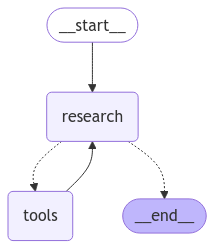

In [14]:
app = workflow.compile()
try:
    display(Image(app.get_graph(xray=True).draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [15]:
inputs = {
    "input": "Hello, I am Sam CTRLman",
}

app.invoke(inputs)

----research node----


{'input': 'Hello, I am Sam CTRLman',
 'messages': [AIMessage(content='Hello Sam CTRLman! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 219, 'total_tokens': 233, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_72ed7ab54c', 'finish_reason': 'stop', 'logprobs': None}, id='run-775138fa-788d-459c-99b1-b27ee39bb265-0', usage_metadata={'input_tokens': 219, 'output_tokens': 14, 'total_tokens': 233, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}

In [16]:
inputs = {
    "input": "What are Small Language Models?",
}

app.invoke(inputs)

----research node----
----research node----


{'input': 'What are Small Language Models?',
 'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_VGR99tQ0bHFfuJiarRAKJKtX', 'function': {'arguments': '{"query":"Small Language Models"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 218, 'total_tokens': 239, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_72ed7ab54c', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run-1e07bd8f-eafe-482a-842f-1dc90e26deb6-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'Small Language Models'}, 'id': 'call_VGR99tQ0bHFfuJiarRAKJKtX', 'type': 'tool_call'}], usage_metadata={'input_tokens': 218, 'output_tokens': 21, '

In [17]:
state = AgentState(**inputs)
for s in app.stream(input=state):
    list(s.values())[0]['messages'][0].pretty_print()
    

----research node----
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (call_DKASVSJNReNqmjOmwYiGZ3ie)
 Call ID: call_DKASVSJNReNqmjOmwYiGZ3ie
  Args:
    query: Small Language Models
================================= Tool Message =================================
Name: tavily_search_results_json

[{"url": "https://www.ibm.com/think/topics/small-language-models", "content": "Small language models (SLMs) are artificial intelligence (AI) models capable of processing, understanding and generating natural language content. As such, SLMs require less memory and computational power, making them ideal for resource-constrained environments such as edge devices and mobile apps, or even for scenarios where AI inferencing—when a model generates a response to a user’s query—must be done offline without a data network. LLMs serve as the base for SLMs. Like large language models, small language models employ a neural network-ba